In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
sns.set_palette("Set2")
from termcolor import colored

In [2]:
path= 'credit_risk_dataset.csv'
df= pd.read_csv(path)

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### EDA

In [5]:
#Questions to answer:
# what are we studying
# how was our data collected
# where, when
# what is the target variable
# based on prior knowledge what features we think influence Y the most, lets explore them.
# outliers / nan values (what do they represent, can they be fixed / ignored)

In [6]:
#1 we are studying unsecured credit loans and their default rate
# to make better decision about credit loan grants in the future.
#2 it appears our data is collected through omitting the person's name & id
# and simply stack the loans that were granted on top of each other, (we'll try to fix that by adding id later)
#3 where and when is not disclosed here
#4 target variable is the loan_status (0 - 1)
#5 All are interesting .

In [7]:
# questions about features influence on y:
# are young people / low income people likely to default ?
# > is that person's a freshman at a company (low p.e.l) and is expected to generate higher incomes
# does the home_ownership status affect the loan_status
# does loan_grade have anything to do with defaults, and are whats the mean age for those with low grade
# does loan_int_rate affect the loan_status or broadly the (l.p.e)
# does the person's default_history affect the loan_status
# does the person's credit_history affect the loan, are youngsters related ?
# loan_amount and its relation with intent and the age/income.
# do we need an indicator 

In [8]:
#checking for duplicated lines
print('Duplicated lines:', len(df[df.duplicated()]))
#fixing that:
df= df[~df.duplicated()]
df.reset_index(drop= True, inplace= True)

Duplicated lines: 165


In [9]:
df[df.duplicated(subset= ['person_age','person_income','person_home_ownership',
                       'person_emp_length','cb_person_default_on_file',
                       'cb_person_cred_hist_length'], keep= False)].shape
# 5835 duplicated lines, means more than one person took multiple loans at once.

(5835, 12)

In [10]:
cols= ['person_age','person_income','person_home_ownership',
                       'person_emp_length','cb_person_default_on_file',
                       'cb_person_cred_hist_length']
df['id']= df.groupby(cols, dropna= False).ngroup()
df['count'] = df.groupby('id', dropna= False)['id'].transform('count')

In [11]:
len(df['id'].unique()) #appears there are 29031 unique people recorded taking loans

29031

In [12]:
colors= ['#4d5359','#fa6d76', '#fafafb', '#fca8ad', '#a3a9af', '#fecacb', '#fb888f', '#fa5560']

In [13]:
# imbalanced data-set 'we're interested in those that defaulted generally
df['loan_status'].value_counts(normalize= True) \
    .mul(100).round(1) \
    .astype('str').add(' %')

loan_status
0    78.1 %
1    21.9 %
Name: proportion, dtype: object

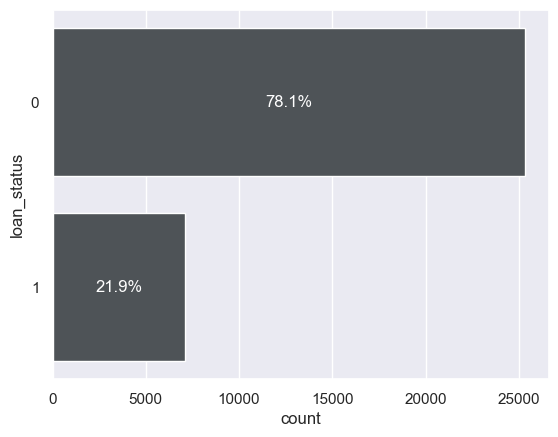

In [14]:
plt.figure()
sns.countplot(data= df, y= 'loan_status', color= colors[0])
plt.bar_label(plt.gca().containers[0], 
             labels=df['loan_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%',
             label_type='center', color='white')
plt.show()

In [15]:
# questions about features influence on y:
# are young people / low income people likely to default ?
# > is that person's a freshman at a company (low p.e.l) and is expected to generate higher incomes
# does the home_ownership status affect the loan_status
# does loan_grade have anything to do with defaults, and are whats the mean age for those with low grade
# does loan_int_rate affect the loan_status or broadly the (l.p.e)
# does the person's default_history affect the loan_status
# does the person's credit_history affect the loan, are youngsters related ?
# loan_amount and its relation with intent and the age/income.
# do we need an indicator 

<Figure size 640x480 with 0 Axes>

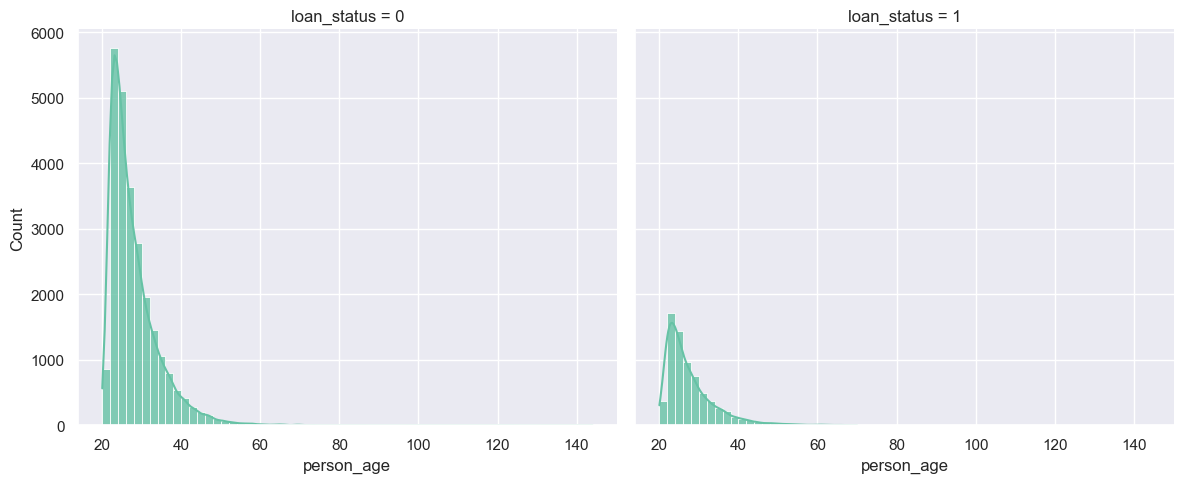

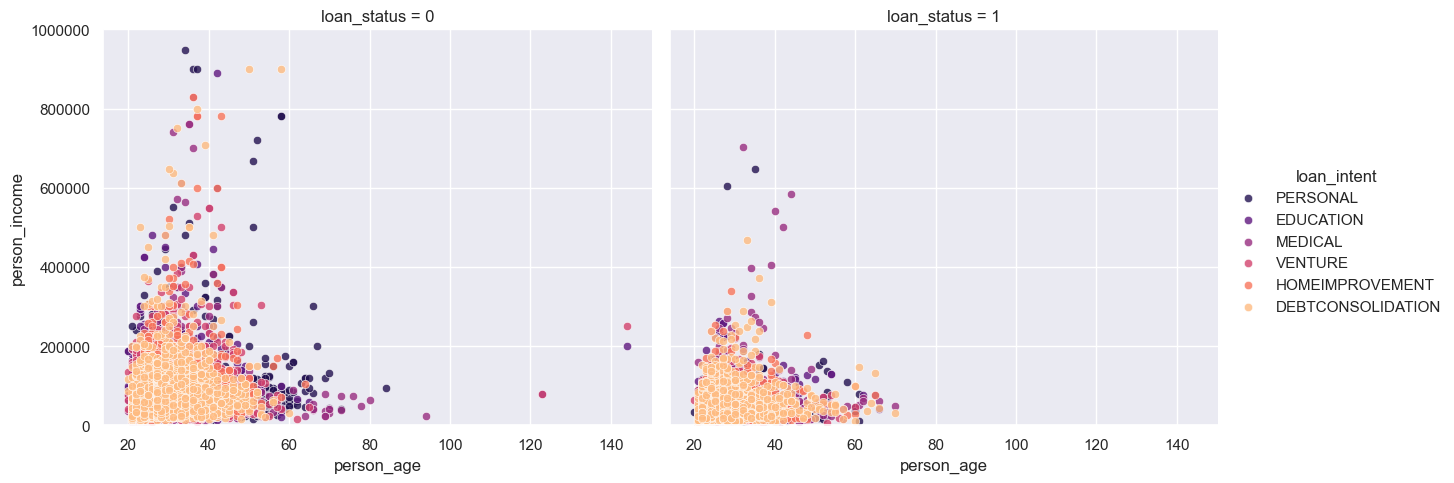

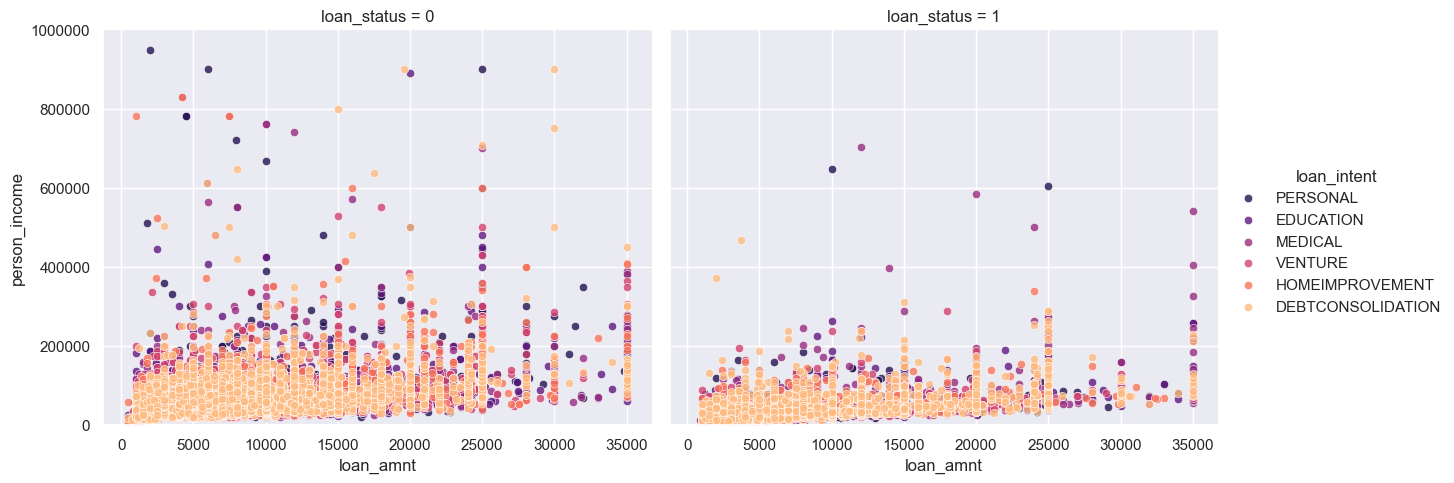

In [16]:
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, palette= 'Dark2')
q.map(sns.histplot, 'person_age', binwidth= 2, kde= True, alpha= .8)
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, hue= 'loan_intent', palette= 'magma')
q.map(sns.scatterplot, 'person_age', 'person_income', alpha= .8)
q.add_legend()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 1000000))
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, hue= 'loan_intent', palette= 'magma')
q.map(sns.scatterplot,'loan_amnt', 'person_income', alpha= .8)
q.add_legend()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 1000000))
plt.show()
# are young people / low income people likely to default ?
# not really people of all ages do default, but there is a clear insight about the income
# those with higher income default less regardless of age.
# outliers appear, we'll deal with them later in preprocessing step (4 loans so far)
# it appears most of those that do default are below 40 yr old, interesting

<Figure size 640x480 with 0 Axes>

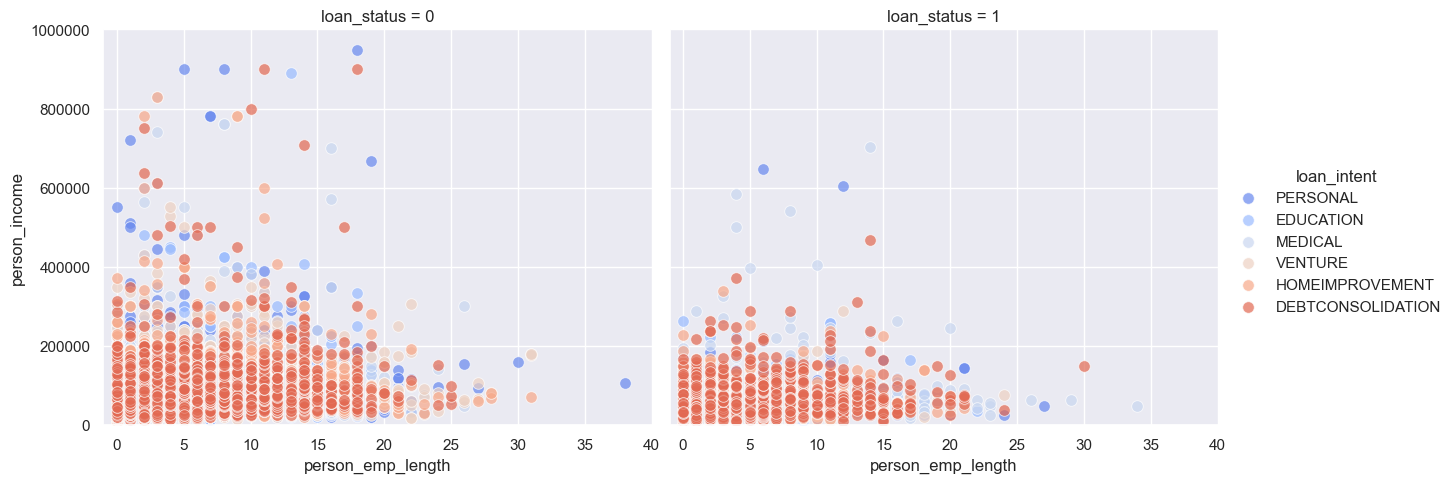

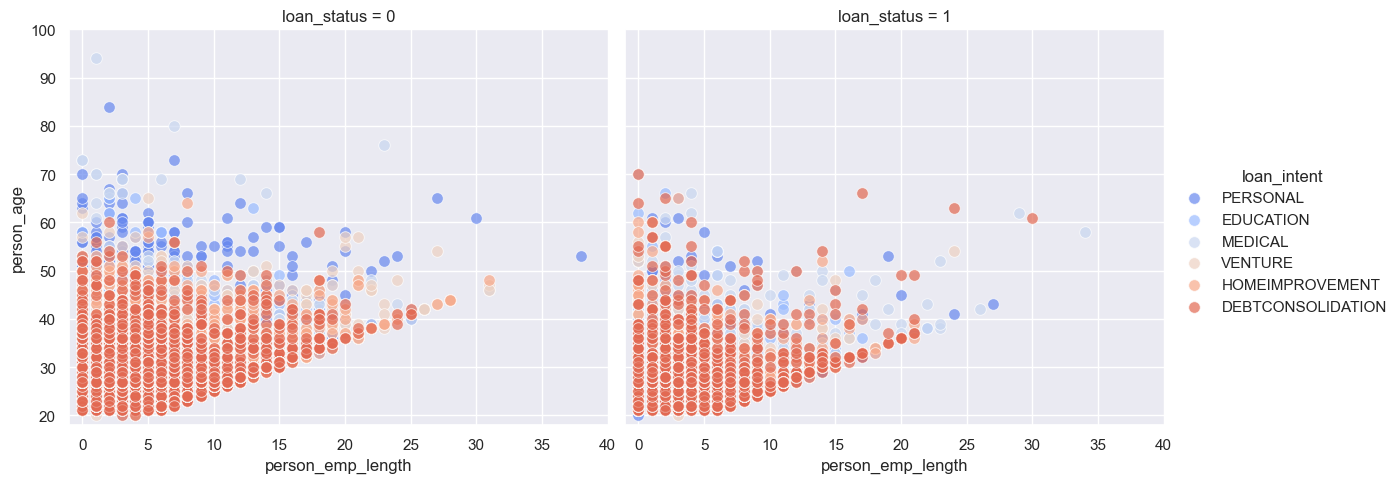

In [17]:
# > is that person's a freshman at a company (low p.e.l) and is expected to generate higher incomes
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', hue='loan_intent', palette= 'coolwarm', height= 5, aspect= 1.2)
q.map(sns.scatterplot, 'person_emp_length', 'person_income', alpha= .7,s= 70)
q.add_legend()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 1000000))
plt.xlim((-1,40))
q= sns.FacetGrid(data= df, col= 'loan_status', hue='loan_intent', palette= 'coolwarm', height= 5, aspect= 1.2)
q.map(sns.scatterplot, 'person_emp_length', 'person_age', alpha= .7,s= 70)
plt.ylim((18, 100))
plt.xlim((-1,40))
q.add_legend()
plt.show()
# there is no clear trend about freshman defaulting, although we see a coned-like shape 
# showing a linear relationship between age and (p.e.l) which is expected

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 640x480 with 0 Axes>

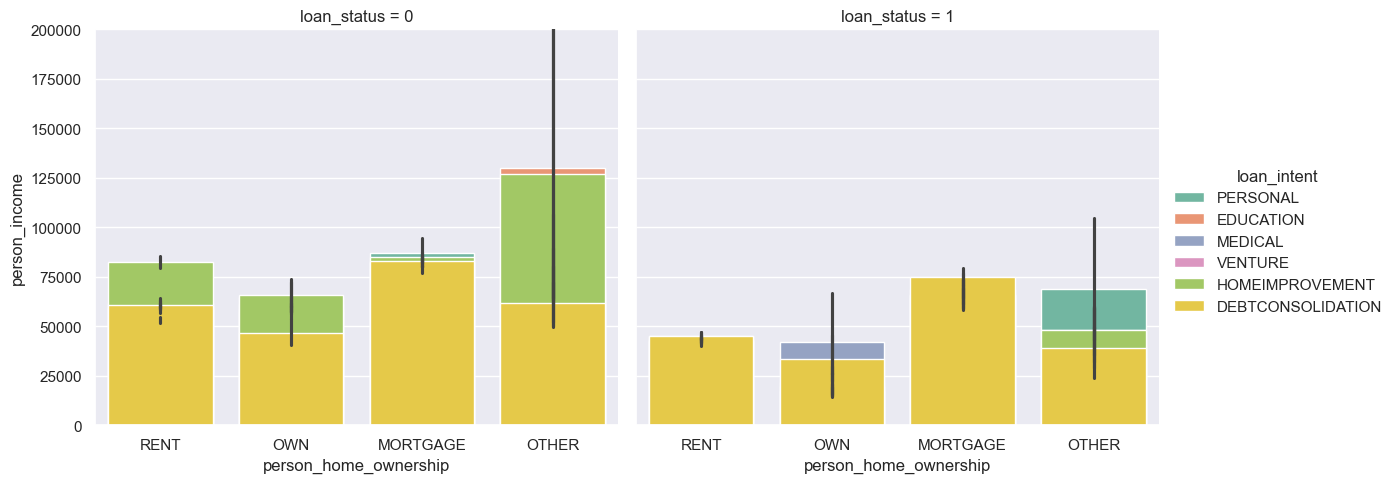

In [18]:
# > what is their financial situation do they rent or own a house
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, hue= 'loan_intent')
q.map(sns.barplot, 'person_home_ownership', 'person_income')
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 200000))
q.add_legend()
plt.show()
#there is a very strong correlation between low wages / rental or mortgage status with loan default
# We could certainly feature engineer a (home_owner) column, we'll do that later

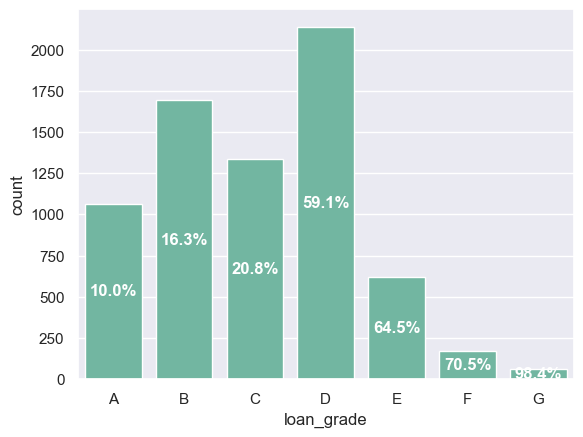

In [19]:
# does loan_grade have anything to do with defaults,
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# 1. Calculate the percentage (mean of loan_status) for each grade
# This is the "Defaults / Total" ratio you requested
percentages = df.groupby('loan_grade')['loan_status'].mean().reindex(grade_order) * 100

# 2. Plot the raw counts of defaults
plt.figure()
ax = sns.countplot(data=df[df['loan_status'] == 1], x='loan_grade', order=grade_order)

# 3. Create string labels (e.g., "50.0%")
pct_labels = [f'{p:.1f}%' for p in percentages]

# 4. Map the labels to the bars
ax.bar_label(ax.containers[0], labels=pct_labels, label_type='center', color='white', weight='bold')
plt.show()
# it appears that loans D/E/F show higher chances of defaulting (percentage sign is their frequency)
# ie their presence in the default status

In [20]:
mask= df['loan_grade'].isin(['D','E','F','G'])
df[mask]['person_age'].describe().round(1)
# strong correlation between bad grade loans and young people (26 yr median)
# could be because they have bad reputation

count    4888.0
mean       27.9
std         6.4
min        20.0
25%        23.0
50%        26.0
75%        30.0
max        70.0
Name: person_age, dtype: float64

<Figure size 640x480 with 0 Axes>

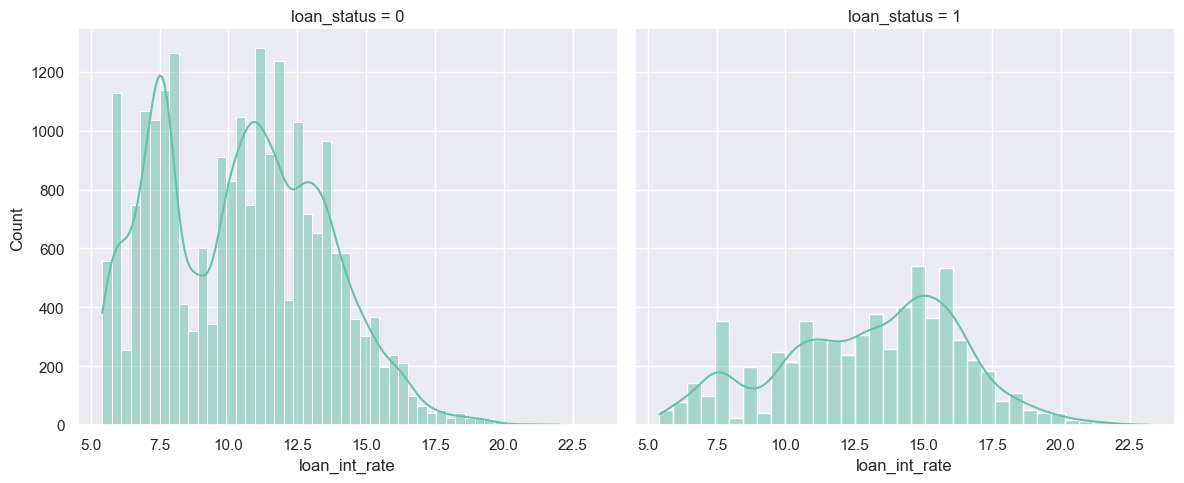

Loan_int_rate Median for defaulted loans: 13.49


In [21]:
# does loan_int_rate affect the loan_status or broadly the (l.p.e)
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', palette= 'Dark2', height= 5,aspect= 1.2)
q.map(sns.histplot, 'loan_int_rate', kde= True)
plt.show()
# Strong correlation that defaulted loan's interest rate cluster in a normal-like shape
print('Loan_int_rate Median for defaulted loans:',df[df['loan_status'] == 1]['loan_int_rate'].median())

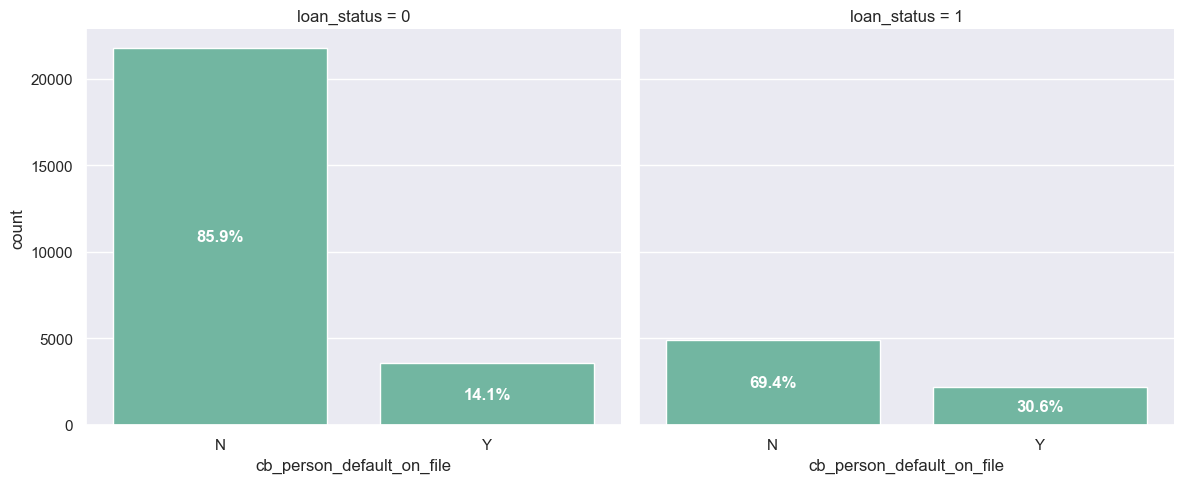

In [22]:
# does the person's default_history affect the loan_status
q = sns.FacetGrid(data=df, col='loan_status', height=5, aspect=1.2)
q.map(sns.countplot, 'cb_person_default_on_file', order=['N', 'Y'])

for ax in q.axes.flat:
    # 1. Calculate the total count for this specific subplot
    total = sum([p.get_height() for p in ax.patches])
    
    # 2. Create labels as a percentage of that total
    labels = [f'{(p.get_height()/total)*100:.1f}%' for p in ax.patches]
    
    # 3. Apply labels
    ax.bar_label(ax.containers[0], labels=labels, label_type='center', color='white', weight='bold')

plt.show()
# it appears that person's default history doesn't give us strong evidence that the person will not
# default, as we see nearly 70% of those that defaulted had clear history of defaults

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


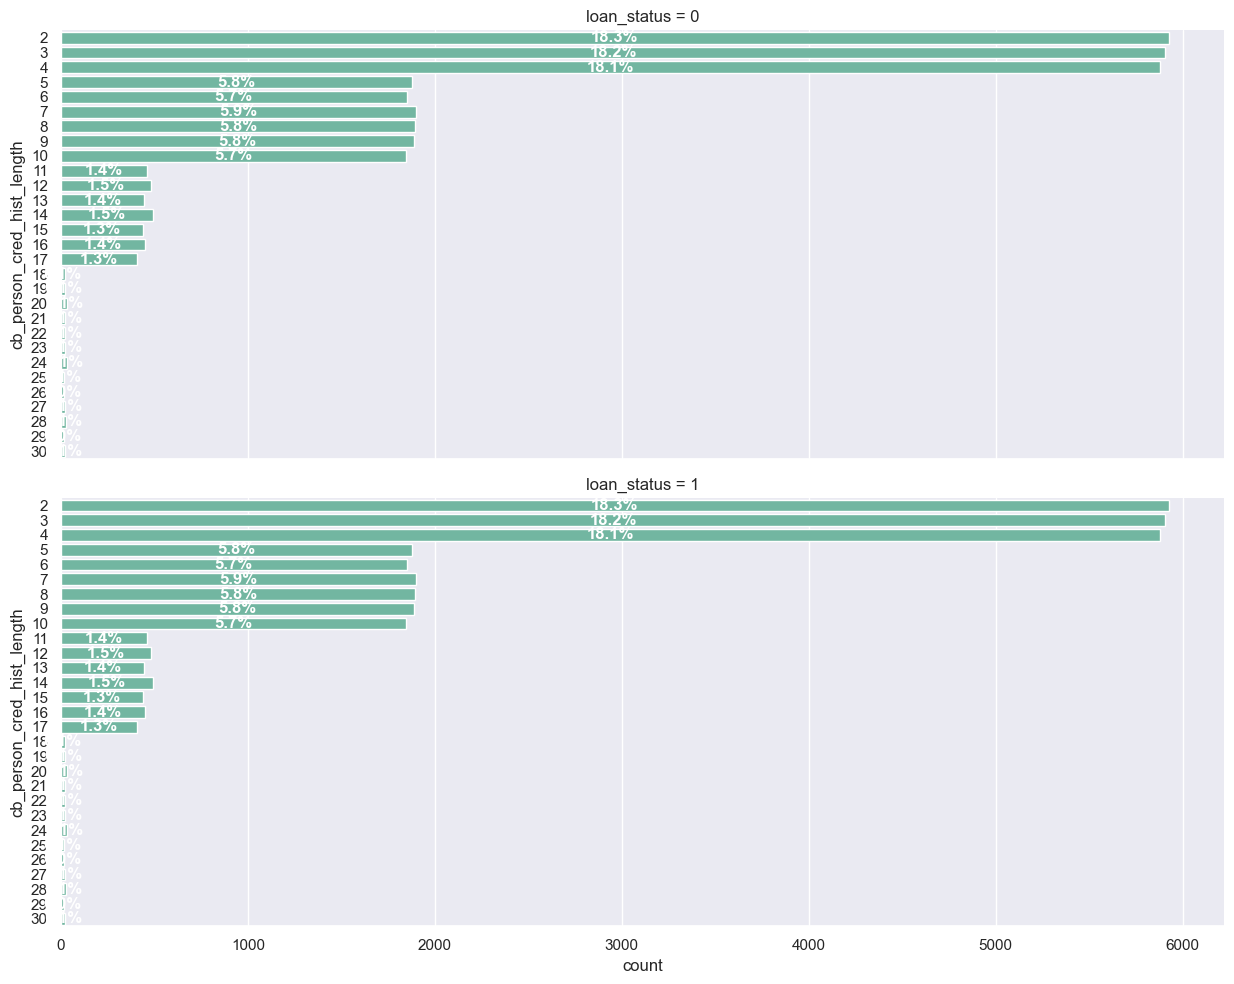

In [23]:
# does the person's credit_history affect the loan, are youngsters related ?
q = sns.FacetGrid(data=df, row='loan_status', height=5, aspect=2.5)

# Pass data=df inside map so it can find the 'y' column
q.map(sns.countplot, y='cb_person_cred_hist_length', data=df)

for ax in q.axes.flat:
    # Use get_width() for horizontal bars
    total = sum([p.get_width() for p in ax.patches if p.get_width() > 0])
    labels = [f'{(p.get_width()/total)*100:.1f}%' if p.get_width() > 0 else '' for p in ax.patches]
    
    ax.bar_label(ax.containers[0], labels=labels, label_type='center', color='white', weight='bold')

plt.show()
# no strong evidence shows that newly created credit accounts default more,
# credit history appear to be the same for both default / non default

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 640x480 with 0 Axes>

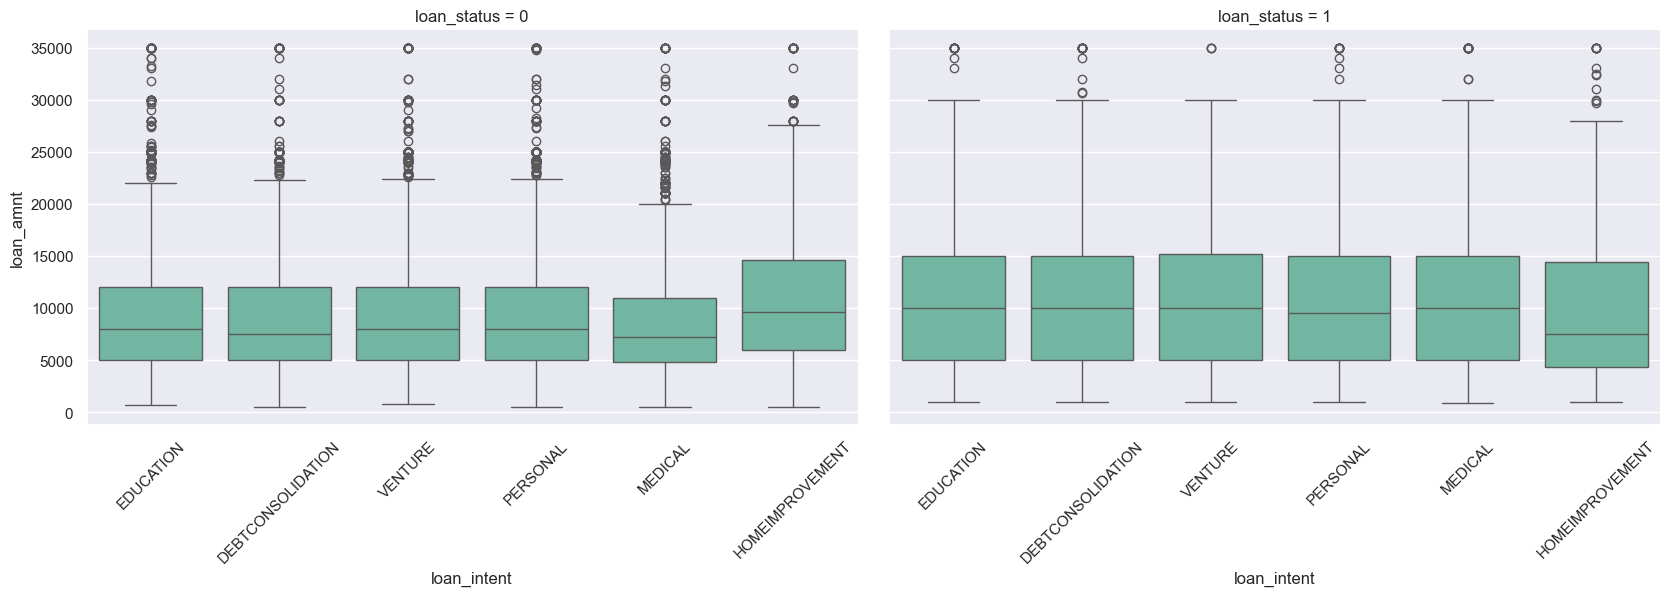

In [24]:
# loan_amount and its relation with intent.
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.7, palette= 'Dark2')
q.map(sns.boxplot, 'loan_intent','loan_amnt')
q.set_xticklabels(rotation=45)
plt.show()
# 3 notes, those that take higher loans for (education / debt consolidation / medical) are more likely to default

In [25]:
mask= df['loan_intent'].isin(['EDUCATION','DEBTCONSOLIDATION','MEDICAL'])
print('default ---------------\n',colored(df[mask][df[mask]['loan_status'] == 1]['loan_amnt'].describe().round(1),color= 'red'),
      '\nnon-default---------------------\n',colored(df[mask][df[mask]['loan_status'] == 0]['loan_amnt'].describe().round(1),color= 'green'))

default ---------------
 count     4211.0
mean     11115.1
std       7177.8
min        900.0
25%       5000.0
50%      10000.0
75%      15000.0
max      35000.0
Name: loan_amnt, dtype: float64 
non-default---------------------
 count    13431.0
mean      8922.0
std       5874.8
min        500.0
25%       5000.0
50%       7500.0
75%      12000.0
max      35000.0
Name: loan_amnt, dtype: float64


In [26]:
#Conclusion:
# so far we noticed:
# 1- higher rates result in higher percentage of defaults regardless of other factors
# (consistent with real world data)
# 2- younger individuals have higher percentages of default overall the younger the borrower is
# the more likely he'll default 
# 3- Home-ownership is a negative predictor of default risk
# 4- loan grades show a promising trend, lower grades consistent with higher defaults.
# LPE (loan percent income) / PEL (person employment length) don't provide much evidence of
# debt burden / income stability in this data-set which is interesting.

### Preprocessing

In [27]:
#dropping outliers.
nan_indicies= []
nan_indicies.extend(df[df['person_emp_length']>41].index)
nan_indicies.extend(df[df['person_age']> 100].index)
df= df.drop(nan_indicies)
df.drop('id', axis= 1, inplace= True)

In [28]:
# exploring why nan are missing starting with (person_emp_length)
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3094
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
count                            0
dtype: int64

In [ ]:
# 1. Create the age groups (bins)
bins = list(range(20, int(df['person_age'].max()) + 5, 5))
df['age_bin'] = pd.cut(df['person_age'], bins=bins, right=False)

# 2. Fill NaNs using the median of each respective age group
df['person_emp_length'] = df['person_emp_length'].fillna(
    df.groupby('age_bin')['person_emp_length'].transform('median')
)

# 3. Remove the temporary bin column
df.drop(columns=['age_bin'], inplace=True)

In [ ]:
# filling the interest rate nan:
df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df.groupby('loan_grade')['loan_int_rate'].transform('median')
)

##### Pipelines

In [33]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split as tts
from sklearn.metrics import classification_report as cr, ConfusionMatrixDisplay as cmd
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [34]:
inputs= df.drop('loan_status', axis= 1)
target= df[['loan_status']]
x_train, x_test, y_train, y_test= tts(inputs, target, random_state= 22, test_size= 0.2, stratify= target)
num_col= inputs.select_dtypes(include= 'number').columns
obj_col= inputs.select_dtypes(include= 'object').columns
num_pipe= Pipeline([
    ('std', StandardScaler())
])
obj_pipe= Pipeline([
    ('encode', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False))
])
preprocessor= ColumnTransformer([
    ('num', num_pipe, num_col),
    ('obj', obj_pipe, obj_col)
])

In [35]:
# 1. Logistic Regression Pipeline
logit_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced'))
])

# 2. Random Forest Pipeline
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced'))
])

# 3. XGBoost Pipeline
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(scale_pos_weight=4))
])

# 4. CatBoost Pipeline
cat_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', CatBoostClassifier(scale_pos_weight=4, verbose=0))
])

In [36]:
model_config = {
    'LogisticRegression': {
        'model': LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],  # Regularization strength
            'model__penalty': ['l1', 'l2']   # Lasso vs Ridge
        }
    },

    'RandomForest': {
        'model': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
        'params': {
            'model__n_estimators': [50, 100, 150],      # Keep low for speed
            'model__max_depth': [5, 10, 15],            # Restrict depth to save RAM
            'model__min_samples_leaf': [2, 5, 10]       # Pruning to prevent overfitting
        }
    },

    'XGBoost': {
        'model': XGBClassifier(scale_pos_weight=4, tree_method='hist', random_state=42, n_jobs=-1),
        'params': {
            'model__learning_rate': [0.05, 0.1, 0.2],
            'model__max_depth': [3, 5, 7],              # XGBoost grows deep fast; keep it shallow
            'model__n_estimators': [100, 200],
            'model__subsample': [0.8, 1.0]              # Stochastic sampling
        }
    },

    'CatBoost': {
        'model': CatBoostClassifier(
            scale_pos_weight=4, 
            verbose=0, 
            random_state=42,
            allow_writing_files=False, # Good for low-end PCs
            cat_features=None          # Force it to treat everything as numeric
        ),
        'params': {
            'model__learning_rate': [0.05, 0.1],
            'model__depth': [4, 6],
            'model__iterations': [150, 300]
        }
}
}

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


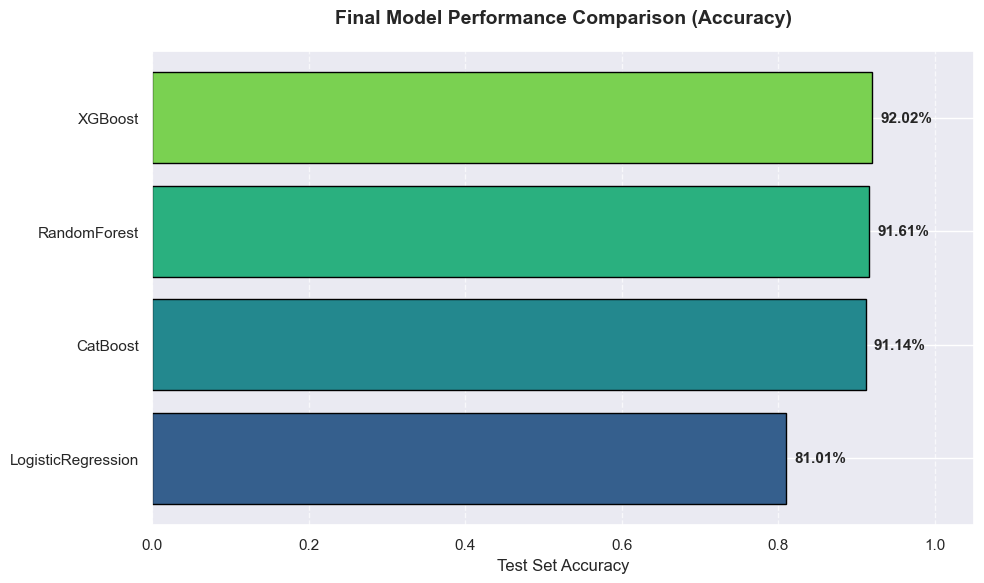

In [37]:
results = {}
best_models = {}
# Loop through the dictionary and execute RandomizedSearchCV
for name, config in model_config.items():
    # Construct the pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['model'])
    ])
    
    # Initialize Search (Optimized for low-end PC)
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=config['params'],
        n_iter=5,          # Low iterations for speed
        cv=3,              # 3-fold cross-validation
        scoring='accuracy',
        n_jobs=-1,         # Use all CPU cores
        random_state=42
    )
    
    # Fit on your training data
    search.fit(x_train, y_train)
    best_models[name] = search
    # Calculate Accuracy on your test set
    test_accuracy = search.score(x_test, y_test)
    results[name] = test_accuracy

# --- Plotting the Results ---
# Convert results to a sorted DataFrame
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=True) # Ascending for horizontal plot order

plt.style.use('seaborn-v0_8-muted') # Nice look
plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(results_df)))
bars = plt.barh(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black')

# Formatting and labels
plt.title('Final Model Performance Comparison (Accuracy)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Test Set Accuracy', fontsize=12)
plt.xlim(0, 1.05) 
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.2%}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [38]:
best_xgb_params = best_models['XGBoost'].best_params_
best_xgb_params

{'model__subsample': 1.0,
 'model__n_estimators': 200,
 'model__max_depth': 7,
 'model__learning_rate': 0.2}

In [39]:
refined_param_grid = {
    'model__n_estimators': [200, 250, 300],      # Increasing slightly
    'model__max_depth': [7, 8, 9],               # Checking if deeper is better
    'model__learning_rate': [0.15, 0.2, 0.25],   # Fine-tuning around 0.2
    'model__subsample': [0.9, 1.0]               # Testing high-sampling stability
}

# Initialize the specific XGBoost Pipeline
xgb_final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(scale_pos_weight=4, tree_method='hist', random_state=42))
])

# Grid Search (Testing all 54 combinations)
grid_search = GridSearchCV(
    estimator=xgb_final_pipe,
    param_grid=refined_param_grid,
    cv=3,
    scoring='accuracy', # Keeping accuracy per your previous code
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.15, 0.2, ...], 'model__max_depth': [7, 8, ...], 'model__n_estimators': [200, 250, ...], 'model__subsample': [0.9, 1.0]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('obj', ...)]"


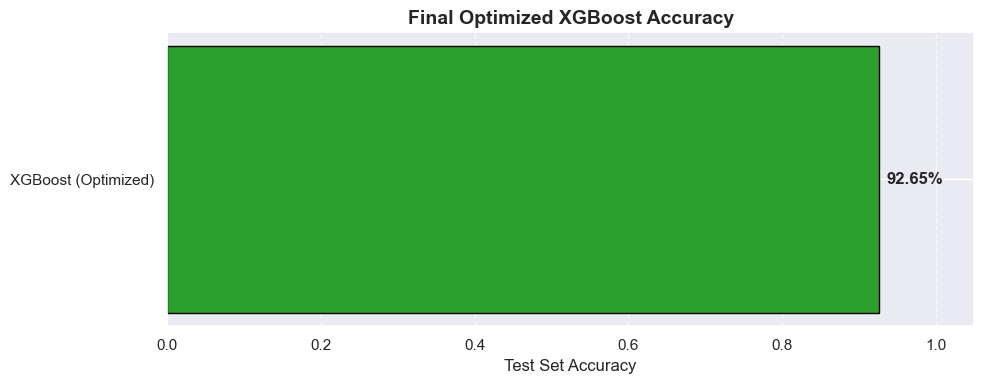

In [40]:
# Evaluate on test set
final_accuracy = grid_search.score(x_test, y_test)

# Data for plotting
final_results = pd.DataFrame({'Model': ['XGBoost (Optimized)'], 'Accuracy': [final_accuracy]})

# Plotting
plt.figure(figsize=(10, 4))
bar = plt.barh(final_results['Model'], final_results['Accuracy'], color='#2ca02c', edgecolor='black')

plt.title('Final Optimized XGBoost Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Test Set Accuracy')
plt.xlim(0, 1.05)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add label
plt.text(final_accuracy + 0.01, 0, f'{final_accuracy:.2%}', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

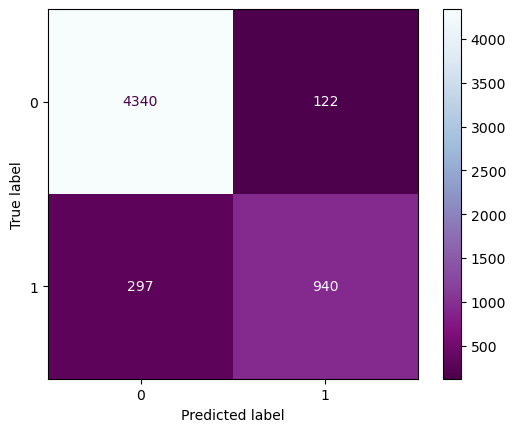

In [41]:
sns.reset_defaults()
plt.figure()
cmd.from_predictions(y_test, grid_search.predict(x_test), cmap= 'BuPu_r')
plt.show()